In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Loan_default.csv")

In [3]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [4]:
df.shape

(255347, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [6]:
df.isnull().sum()

,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


In [7]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


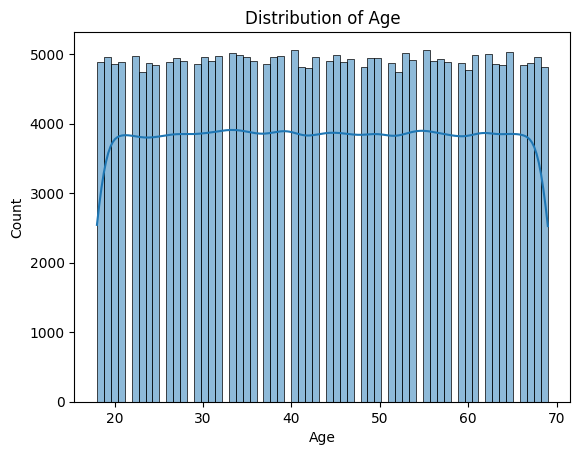

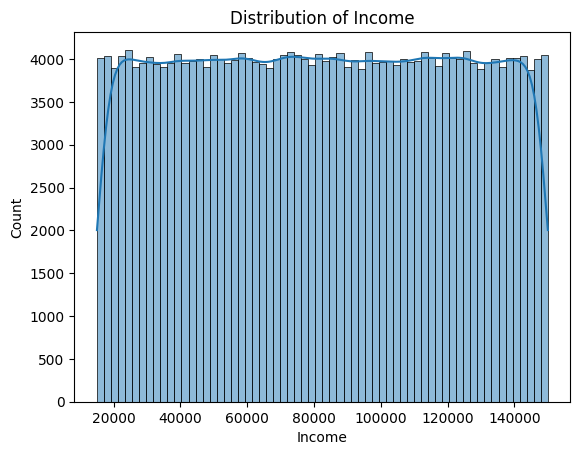

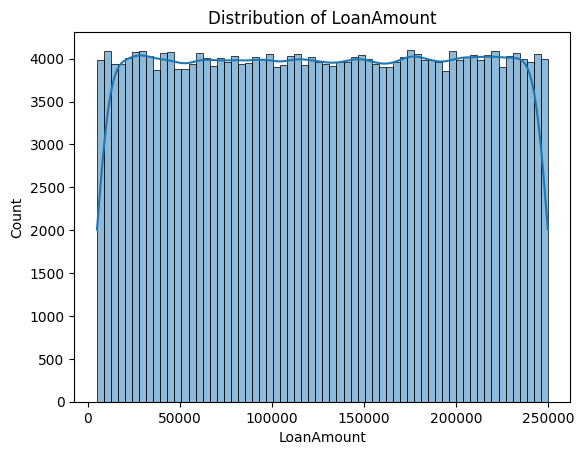

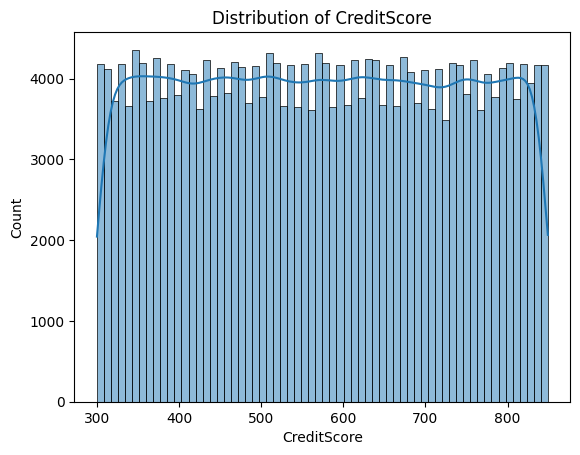

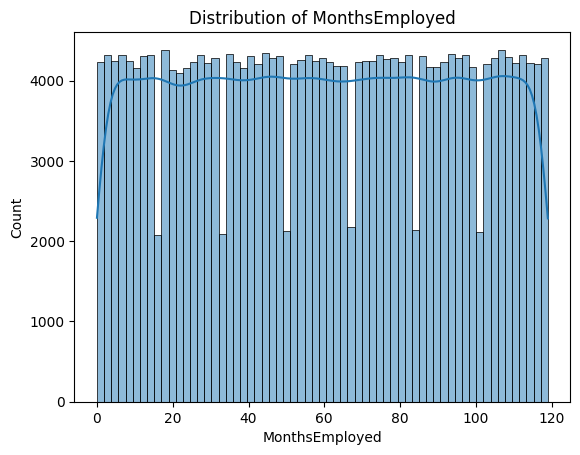

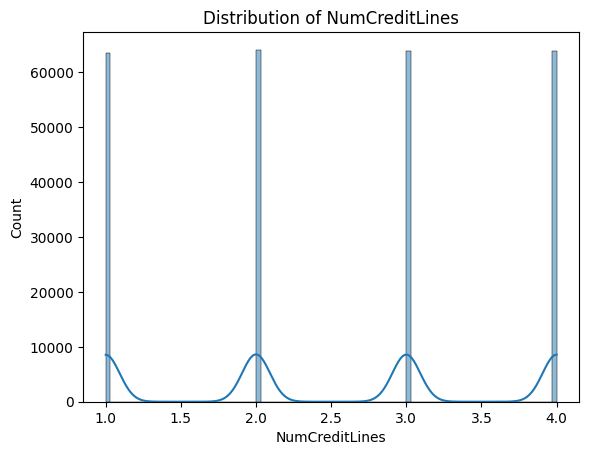

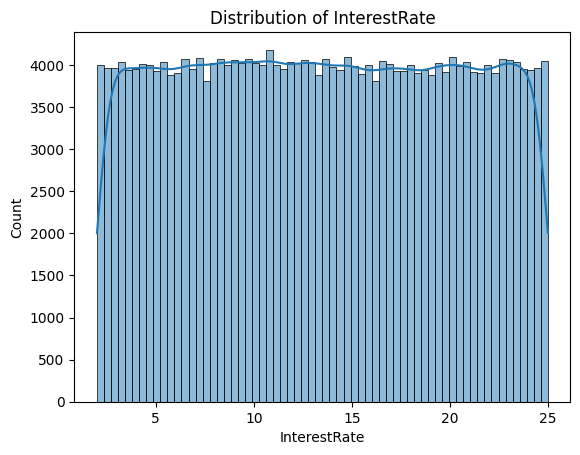

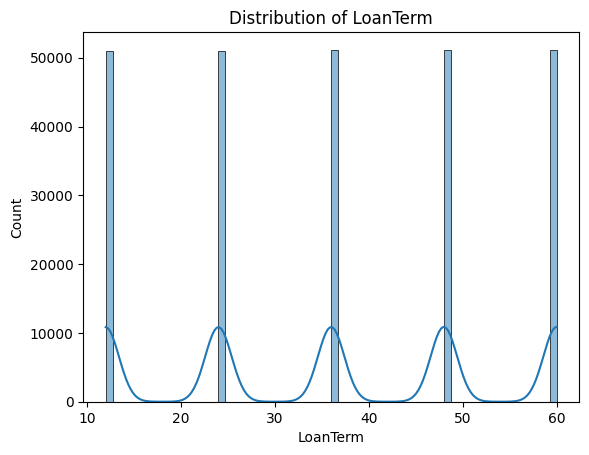

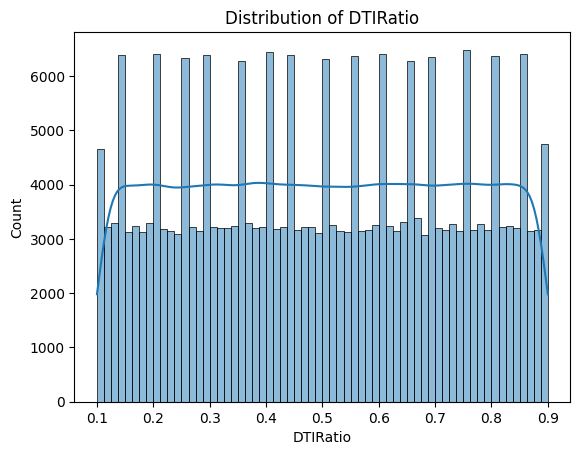

In [8]:
num_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore',
            'MonthsEmployed', 'NumCreditLines',
            'InterestRate', 'LoanTerm', 'DTIRatio']

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

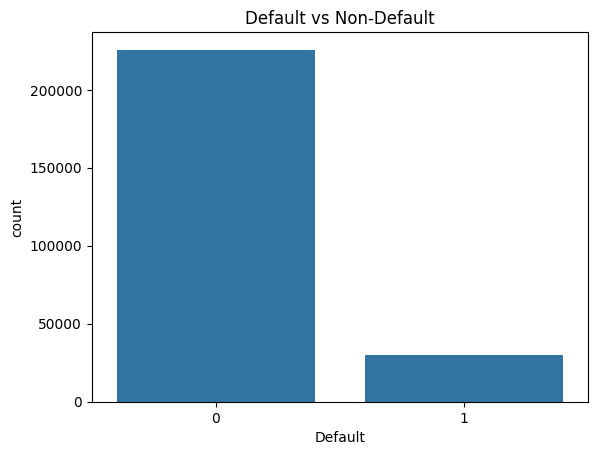

Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64


In [9]:
sns.countplot(x='Default', data=df)
plt.title("Default vs Non-Default")
plt.show()
default_rate = df['Default'].value_counts(normalize=True) * 100
print(default_rate)

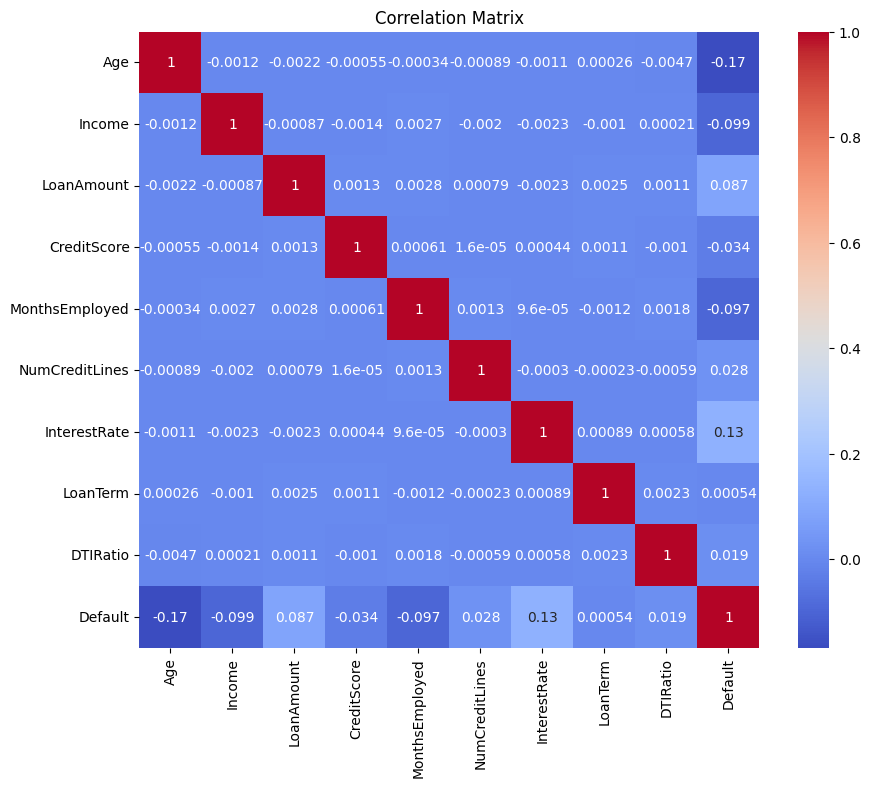

In [10]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [11]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

outliers = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outliers[col] = count

print("Outliers per column:")
print(outliers)

Outliers per column:
{'Age': 0, 'Income': 0, 'LoanAmount': 0, 'CreditScore': 0, 'MonthsEmployed': 0, 'NumCreditLines': 0, 'InterestRate': 0, 'LoanTerm': 0, 'DTIRatio': 0, 'Default': 29653}


In [12]:
df["Loan_to_Income"] = df["LoanAmount"] / df["Income"]
df["EMI_Burden"] = df["LoanAmount"] / df["LoanTerm"]
df["Income_per_CreditLine"] = df["Income"] / df["NumCreditLines"]

In [13]:
df["Employment_Stability"] = df["MonthsEmployed"] / df["Age"]

df["Income_Stability"] = df["Income"] / (df["MonthsEmployed"] + 1)

In [14]:
df["CreditLines_per_Income"] = df["NumCreditLines"] / df["Income"]

df["CreditScore_per_Income"] = df["CreditScore"] / df["Income"]

In [15]:
df["Risk_Score"] = (
    df["DTIRatio"] * 0.4 +
    df["InterestRate"] * 0.3 +
    (1 / df["CreditScore"]) * 0.3
)

In [16]:
df.replace([np.inf, -np.inf], 0, inplace=True)
df.fillna(0, inplace=True)

In [17]:
from sklearn.model_selection import train_test_split

df.drop("LoanID", axis=1, inplace=True, errors="ignore")

X = df.drop("Default", axis=1)
y = df["Default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
)


In [18]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])


In [19]:
preprocessor.fit(X_train)

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_transformed, y_train)

print('Before SMOTE ” Class 0:', (y_train==0).sum(), '| Class 1:', (y_train==1).sum())
print('After  SMOTE ” Class 0:', (y_train_res==0).sum(), '| Class 1:', (y_train_res==1).sum())


Before SMOTE â€” Class 0: 180524 | Class 1: 23753
After  SMOTE â€” Class 0: 180524 | Class 1: 180524


In [21]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train_res, y_train_res)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train_res, y_train_res)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [23]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train_res, y_train_res)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

              precision    recall  f1-score   support

           0       0.94      0.70      0.80     45170
           1       0.23      0.69      0.34      5900

    accuracy                           0.70     51070
   macro avg       0.59      0.69      0.57     51070
weighted avg       0.86      0.70      0.75     51070

ROC-AUC : 0.7602969985328495


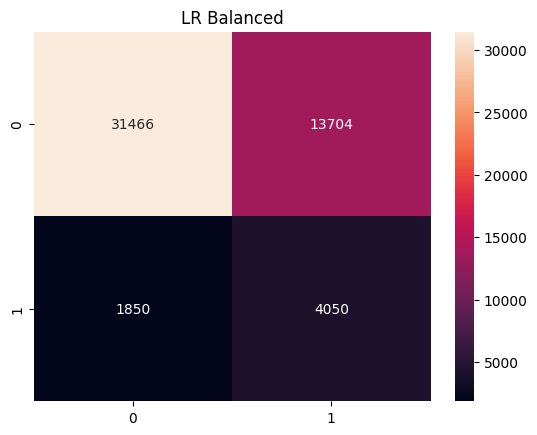

In [24]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
y_pred = lr.predict(X_test_transformed)
y_prob = lr.predict_proba(X_test_transformed)[:,1]
print(classification_report(y_test, y_pred))
print("ROC-AUC :", roc_auc_score(y_test, y_prob))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("LR Balanced")
plt.show()

              precision    recall  f1-score   support

           0       0.89      0.98      0.94     45170
           1       0.47      0.11      0.17      5900

    accuracy                           0.88     51070
   macro avg       0.68      0.55      0.56     51070
weighted avg       0.84      0.88      0.85     51070

ROC-AUC : 0.7323497409034795


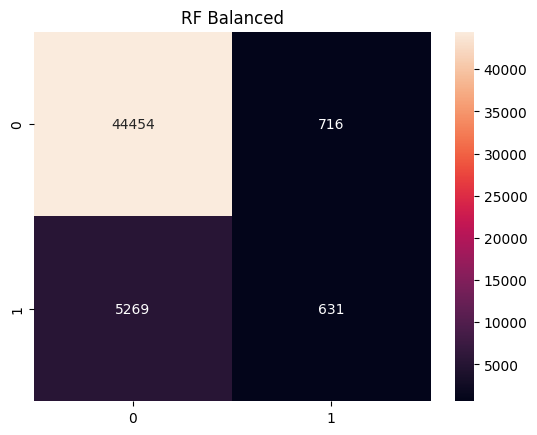

In [25]:
y_pred = rf.predict(X_test_transformed)
y_prob = rf.predict_proba(X_test_transformed)[:,1]
print(classification_report(y_test, y_pred))
print("ROC-AUC :", roc_auc_score(y_test, y_prob))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("RF Balanced")
plt.show()

              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45170
           1       0.55      0.09      0.15      5900

    accuracy                           0.89     51070
   macro avg       0.72      0.54      0.54     51070
weighted avg       0.85      0.89      0.85     51070

ROC-AUC : 0.7454376761237209


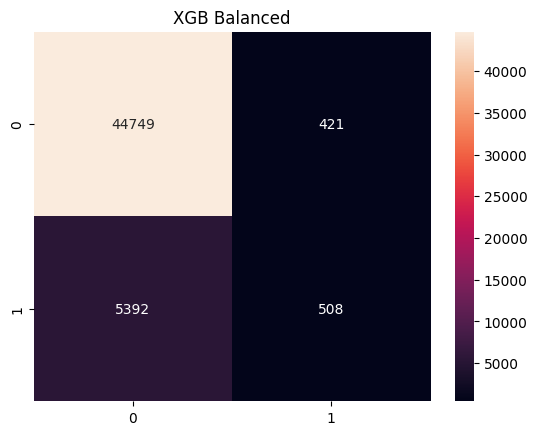

In [26]:
y_pred = xgb.predict(X_test_transformed)
y_prob = xgb.predict_proba(X_test_transformed)[:,1]
print(classification_report(y_test, y_pred))
print("ROC-AUC :", roc_auc_score(y_test, y_prob))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("XGB Balanced")
plt.show()

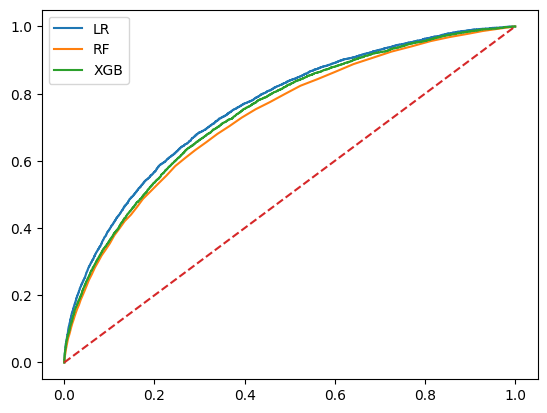

In [27]:
from sklearn.metrics import roc_curve

def plot_roc(model, name):
    y_prob = model.predict_proba(X_test_transformed)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.figure()
plot_roc(lr, "LR")
plot_roc(rf, "RF")
plot_roc(xgb, "XGB")

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.show()

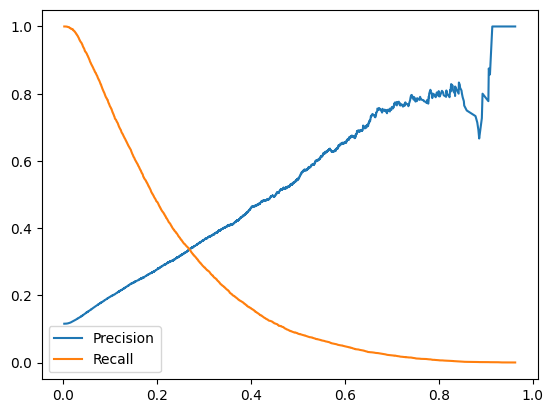

In [28]:
from sklearn.metrics import precision_recall_curve

y_prob = xgb.predict_proba(X_test_transformed)[:,1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.legend()
plt.show()

In [29]:
y_prob = lr.predict_proba(X_test_transformed)[:, 1]
y_pred_custom = (y_prob > 0.25).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.97      0.30      0.46     45170
           1       0.15      0.93      0.26      5900

    accuracy                           0.37     51070
   macro avg       0.56      0.62      0.36     51070
weighted avg       0.88      0.37      0.43     51070



In [30]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1]
}

grid = GridSearchCV(xgb, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train_res, y_train_res)

best_xgb = grid.best_estimator_
print('Best params:', grid.best_params_)


Best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}


In [31]:
y_pred = best_xgb.predict(X_test_transformed)
y_prob = best_xgb.predict_proba(X_test_transformed)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45170
           1       0.58      0.09      0.15      5900

    accuracy                           0.89     51070
   macro avg       0.74      0.54      0.55     51070
weighted avg       0.86      0.89      0.85     51070

ROC-AUC: 0.7534904353797143


In [32]:
importances = best_xgb.feature_importances_
features = preprocessor.get_feature_names_out()

pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(10)

,Feature,Importance
29,cat__HasMortgage_Yes,0.129381
38,cat__HasCoSigner_Yes,0.108194
31,cat__HasDependents_Yes,0.104711
20,cat__Education_PhD,0.060486
26,cat__MaritalStatus_Married,0.046780
35,cat__LoanPurpose_Home,0.042116
24,cat__EmploymentType_Unemployed,0.038720
19,cat__Education_Master's,0.037631
18,cat__Education_High School,0.034661
34,cat__LoanPurpose_Education,0.033517


In [35]:
test_cases = pd.DataFrame([

    {
        "Age": 40,
        "Income": 80000,
        "LoanAmount": 100000,
        "CreditScore": 750,
        "MonthsEmployed": 120,
        "NumCreditLines": 2,
        "InterestRate": 8,
        "LoanTerm": 36,
        "DTIRatio": 0.2,
        "Education": "Master's",
        "EmploymentType": "Full-time",
        "MaritalStatus": "Married",
        "HasMortgage": "No",
        "HasDependents": "No",
        "LoanPurpose": "Home",
        "HasCoSigner": "No"
    },


    {
        "Age": 22,
        "Income": 20000,
        "LoanAmount": 150000,
        "CreditScore": 550,
        "MonthsEmployed": 6,
        "NumCreditLines": 5,
        "InterestRate": 18,
        "LoanTerm": 60,
        "DTIRatio": 0.7,
        "Education": "High School",
        "EmploymentType": "Unemployed",
        "MaritalStatus": "Single",
        "HasMortgage": "Yes",
        "HasDependents": "Yes",
        "LoanPurpose": "Personal",
        "HasCoSigner": "No"
    }
])

In [36]:
test_cases["Loan_to_Income"] = test_cases["LoanAmount"] / test_cases["Income"]
test_cases["EMI_Burden"] = test_cases["LoanAmount"] / test_cases["LoanTerm"]
test_cases["Income_per_CreditLine"] = test_cases["Income"] / test_cases["NumCreditLines"]

test_cases["Employment_Stability"] = test_cases["MonthsEmployed"] / test_cases["Age"]
test_cases["Income_Stability"] = test_cases["Income"] / (test_cases["MonthsEmployed"] + 1)

test_cases["CreditLines_per_Income"] = test_cases["NumCreditLines"] / test_cases["Income"]
test_cases["CreditScore_per_Income"] = test_cases["CreditScore"] / test_cases["Income"]

test_cases["Risk_Score"] = (
    test_cases["DTIRatio"] * 0.4 +
    test_cases["InterestRate"] * 0.3 +
    (1 / test_cases["CreditScore"]) * 0.3
)

test_cases.replace([np.inf, -np.inf], 0, inplace=True)
test_cases.fillna(0, inplace=True)

In [38]:
test_transformed = preprocessor.transform(test_cases)

probs = model.predict_proba(test_transformed)[:,1]
preds = (probs > 0.3).astype(int)

for i in range(len(test_cases)):
    print(f"\nCASE {i+1}")
    print("Probability:", round(probs[i], 3))
    print("Prediction:", "Default" if preds[i]==1 else "Safe ")


CASE 1
Probability: 0.042
Prediction: Safe 

CASE 2
Probability: 0.674
Prediction: Default
